In [1]:
!pip install stanza tqdm -q

In [ ]:
import pandas as pd
import stanza
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import re

C:\Users\Wede\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 2. Data Loading and Model Initialization ---
try:
    df = pd.read_csv('../Week2/df_rosaliarev_raw.csv')
    df['content'].fillna('', inplace=True)
    print("✅ Raw file 'df_rosaliarev_raw.csv' loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'df_rosaliarev_raw.csv' not found.")
    exit()

print("\nDownloading the Indonesian model for Stanza...")
stanza.download('id')

print("Initializing the Stanza pipeline...")
nlp = stanza.Pipeline('id', processors='tokenize,pos,lemma', verbose=False)
print("✅ Pipeline is ready.")

C:\Users\Wede\AppData\Local\Temp\ipykernel_12812\160013537.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['content'].fillna('', inplace=True)


✅ Raw file 'df_rosaliarev_raw.csv' loaded successfully.



2025-10-18 03:30:13 INFO: Downloaded file to C:\Users\Wede\stanza_resources\resources.json
2025-10-18 03:30:13 INFO: Downloading default packages for language: id (Indonesian) ...
2025-10-18 03:30:15 INFO: File exists: C:\Users\Wede\stanza_resources\id\default.zip
2025-10-18 03:30:19 INFO: Finished downloading models and saved to C:\Users\Wede\stanza_resources


Initializing the Stanza pipeline...
✅ Pipeline is ready.


In [3]:
# --- 3. Preprocessing for POS Tagging ---
kamus_normalisasi = {
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'tdk': 'tidak',
    'jg': 'juga', 'jd': 'jadi', 'utk': 'untuk', 'aja': 'saja', 'udh': 'sudah',
    'tp': 'tapi', 'bgt': 'banget', 'lg': 'lagi', 'dgn': 'dengan', 'bs': 'bisa',
    'klo': 'kalau', 'kalo': 'kalau', 'sih': 'sih', 'nya': '', 'kok': 'kok',
    'kyk': 'seperti', 'dlm': 'dalam', 'pas': 'saat', 'krn': 'karena', 'min': 'admin',
    'apk': 'aplikasi', 'app': 'aplikasi'
}

def preprocess_for_pos_with_normalization(text):
    text = str(text).lower()
    words = text.split()
    normalized_words = [kamus_normalisasi.get(w, w) for w in words]
    text = ' '.join(normalized_words)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['pos_input_text'] = df['content'].apply(preprocess_for_pos_with_normalization)
print("\n'pos_input_text' column (with normalization) has been created.")


'pos_input_text' column (with normalization) has been created.


In [4]:
# --- 4. POS Tagging Process ---
sample_df = df.copy()
sentences_with_tags = []

print(f"\nStarting POS Tagging on {len(sample_df)} reviews...")
for review in tqdm(sample_df['pos_input_text'], desc="POS Tagging Reviews"):
    if not review.strip():
        continue
    doc = nlp(review)
    for sent in doc.sentences:
        # Store a list of (word_lemma, pos_tag) for each sentence
        sentences_with_tags.append([(word.lemma, word.upos) for word in sent.words])

print("\n✅ POS Tagging complete.")


Starting POS Tagging on 3973 reviews...


POS Tagging Reviews: 100%|██████████| 3973/3973 [19:06<00:00,  3.46it/s]  


✅ POS Tagging complete.


In [5]:
# --- 5. Extracting Adjective-Noun Pairs ---
print("COMMON ADJECTIVE-NOUN PHRASES")

adj_noun_pairs = []
for sentence in sentences_with_tags:
    for i in range(len(sentence) - 1):
        # Check for the pattern: Adjective followed by a Noun
        if sentence[i][1] == 'ADJ' and sentence[i+1][1] == 'NOUN':
            # Combine the adjective and noun into a single phrase
            pair = f"{sentence[i][0]} {sentence[i+1][0]}"
            adj_noun_pairs.append(pair)

# Count the frequency of each pair
pair_counts = Counter(adj_noun_pairs)
top_pairs_df = pd.DataFrame(pair_counts.most_common(20), columns=['Phrase (Adjective-Noun)', 'Frequency'])

print("\n--- Top 20 Most Common Descriptive Phrases ---")
display(top_pairs_df)

COMMON ADJECTIVE-NOUN PHRASES

--- Top 20 Most Common Descriptive Phrases ---


,Phrase (Adjective-Noun),Frequency
0,tepat waktu,31
1,habis update,13
2,pertama kali,12
3,bagus aplikasi,11
4,kaya gini,8
5,bagus layan,7
6,indah transport,6
7,telat menit,5
8,nyaman layan,5
9,jauh hari,5


C:\Users\Wede\AppData\Local\Temp\ipykernel_12812\1998285376.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='POS_Tag', data=pos_df, palette='magma')


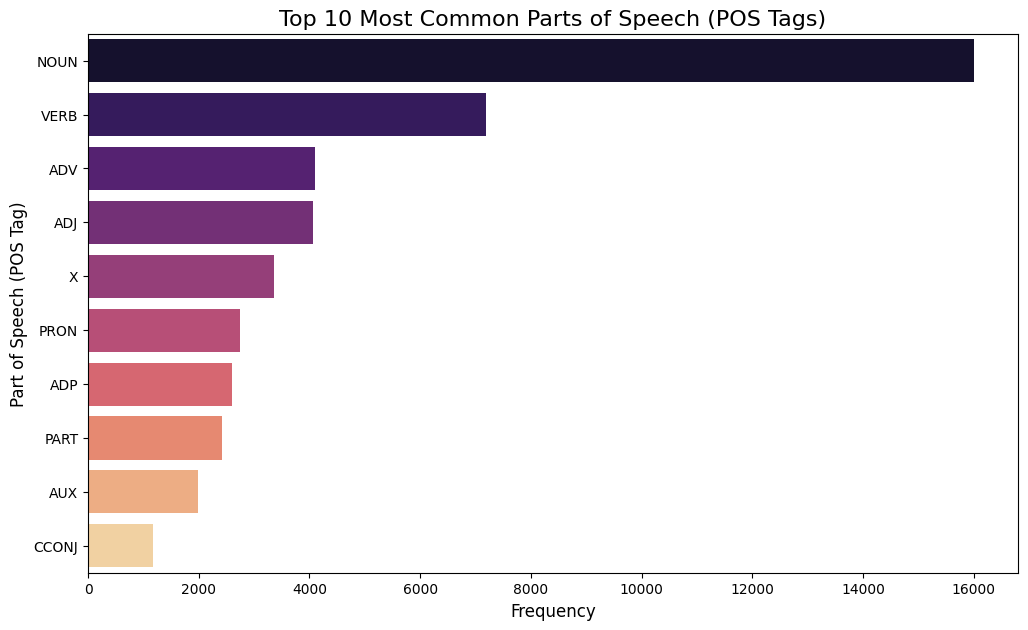


--- Top 15 Nouns ---
        Noun  Count
0   aplikasi   1133
1      tiket    666
2        bus    331
3       kode    298
4    rosalia    292
5      layan    263
6       agen    248
7      pesan    225
8        jam    203
9     update    199
10     bayar    195
11    daftar    155
12     email    155
13       otp    143
14       bis    134

--- Top 15 Adjectives ---
   Adjective  Count
0      bagus    289
1      indah    192
2      susah    185
3       baik    178
4     online    148
5     nyaman    137
6       sama    135
7     mantap    130
8      mudah    126
9       lama     88
10      baru     87
11      lain     80
12     habis     75
13     ribet     66
14       top     59


In [6]:
# --- Basic POS Distribution and Keyword Extraction ---
# This part is still useful for a general overview.
all_tagged_words = [item for sublist in sentences_with_tags for item in sublist]
all_pos_tags = [tag for word, tag in all_tagged_words]

pos_counts = Counter(all_pos_tags)
pos_df = pd.DataFrame(pos_counts.most_common(10), columns=['POS_Tag', 'Frequency'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Frequency', y='POS_Tag', data=pos_df, palette='magma')
plt.title('Top 10 Most Common Parts of Speech (POS Tags)', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Part of Speech (POS Tag)', fontsize=12)
plt.show()

def get_top_words_by_tag(tagged_words, tag, n=15):
    words_with_tag = [word for word, pos_tag in tagged_words if pos_tag == tag and word is not None]
    return Counter(words_with_tag).most_common(n)

top_nouns = get_top_words_by_tag(all_tagged_words, 'NOUN')
print("\n--- Top 15 Nouns ---")
print(pd.DataFrame(top_nouns, columns=['Noun', 'Count']))

top_adjectives = get_top_words_by_tag(all_tagged_words, 'ADJ')
print("\n--- Top 15 Adjectives ---")
print(pd.DataFrame(top_adjectives, columns=['Adjective', 'Count']))